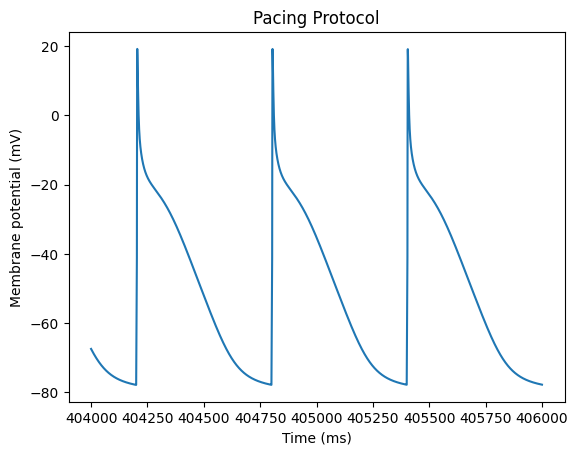

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


stim_sequence = [
    {"n_beats": 200,
     "cycle_length": 1000.,
     "stim_duration": 2,
     "stim_amplitude": 20.,
     "dt": 0.005},
    {"n_beats": 10,
     "cycle_length": 300.,
     "stim_duration": 2,
     "stim_amplitude": 20.,
     "dt": 0.005},
    #  {"n_beats": 3,
    #  "cycle_length": 300.,
    #  "stim_duration": 0.5,
    #  "stim_amplitude": 100.,
    #  "dt": 0.01},
]

dt = 0.01
# create a tissue of size 400x400 with cardiomycytes:
cardiac_model = fw.Courtemanche()
cardiac_model.prepacing(stim_sequence)
state_vars = cardiac_model.collect_states(0.01, 300, 2, 20.)

time = np.arange(0, len(cardiac_model.u_pacing)*dt, dt)

plt.plot(time[-200000:], cardiac_model.u_pacing[-200000:])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Pacing Protocol")
plt.show()

In [11]:
import inspect
import ast


def foo(x, y):
    """
    Multiline docstring example.
    
    Parameters
    ----------
    x : int
        First integer.
    y : int
        Second integer.
    """
    z = x + y

    d = "'dfdfdf'"

    z = z * 2

    d = """dfdfgdfg"""

    z = z - 1

    d = "dfdf"
    return (z,
            d)


def extract_func_body(func):
    src = inspect.getsource(func)
    tree = ast.parse(src)

    func_node = tree.body[0]

    new_body = []
    for node in func_node.body:
        # Remove docstring
        if (
            isinstance(node, ast.Expr)
            and isinstance(node.value, ast.Constant)
            and isinstance(node.value.value, str)
        ):
            continue

        # Skip all return statements completely
        if isinstance(node, ast.Return):
            continue

        new_body.append(node)

    module = ast.Module(body=new_body, type_ignores=[])
    return ast.unparse(module)


src = inspect.getsource(foo)
extract_func_body(foo)

'z = x + y\nd = "\'dfdfdf\'"\nz = z * 2\nd = \'dfdfgdfg\'\nz = z - 1\nd = \'dfdf\''

In [20]:
arrays = ['x', 'y', 'z']
state_vars = ['z', 'y']
params = ['a', 'b']


def indexing(var):
    return f"{var}.flat[i]"

asign_vars = "\n".join(f"{var}_old = {indexing(var)}" for var in arrays)

step_body = f"""\
y_new = y_old + a * x_old
z_new = z_old + b * y_old
"""

update_vars = "\n".join(f"{indexing(var)} = {var}_new" for var in state_vars)

body = f"""\
{asign_vars}
{step_body}
{update_vars}
"""

print(body)

x_old = x.flat[i]
y_old = y.flat[i]
z_old = z.flat[i]
y_new = y_old + a * x_old
z_new = z_old + b * y_old

z.flat[i] = z_new
y.flat[i] = y_new



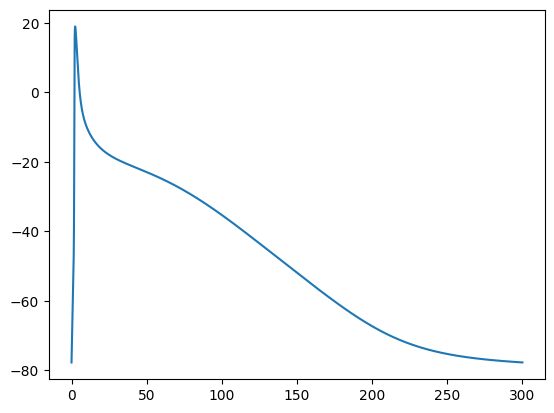

In [32]:

# plt.plot(state_vars['u'])
time = np.arange(0, len(state_vars['u'])*dt, dt)
plt.plot(time, state_vars['u'])
plt.show()

In [53]:
from pathlib import Path
import pyvista as pv
import numpy as np
import finitewave as fw


path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")

vtk_mesh = pv.read(path / "Mesh_10954794.vtk")
lat_map = np.load(path / "lat_map_100.npy")

lat_tacker = fw.LocalActivationTimeTracker()
lat_tacker.act_t = lat_map

path_save = Path("/Users/arstanbekokenov/Projects/Finitewave/lat_data")

period = 27.3

for i, dt in enumerate(np.linspace(0, 0 + 4*period, 400)):
    lat_map_x = lat_tacker.activation_map(dt, dt + period)
    lat_map_x -= dt
    
    lat_map_x[np.isnan(lat_map_x)] = 0
    lat_map_x[lat_map_x > period] = 0
    lat_map_x[lat_map_x < 0] = 0

    np.save(path_save / f"{i}.npy", lat_map_x)

vtk_mesh['lat'] = lat_map_x.copy()

pl = pv.Plotter()
pl.add_mesh(vtk_mesh, scalars='lat', cmap='magma', show_edges=False)
pl.camera_position = 'zy'
pl.show()

Widget(value='<iframe src="http://localhost:49470/index.html?ui=P_0x3f504bf10_45&reconnect=auto" class="pyvist…

In [43]:
lat_map

array([[-1. , -1. , -1. , ...,  5.5, -1. , -1. ],
       [30.4, 30.4, 30.5, ..., 34.6, 26.5, 21.8],
       [57.5, 57.5, 57.6, ..., 58.3, 53.8, 45.3],
       [-1. , -1. , -1. , ..., 81.4, 82.3, 72.2],
       [84.7, 84.7, 84.6, ..., -1. , -1. , 98.9]], shape=(5, 145134))

In [28]:
len(np.linspace(0, 1, 10))

10

In [26]:
lat_map_x = lat_map.copy()
lat_map_x[lat_map_x > 26] = 26
lat_map_x[lat_map_x < 0] = 0

lat_map_x = 299 -lat_map_x / 26 * 299
lat_map_x = lat_map_x.astype(np.int64)

u_map = state_vars['u'][::100][lat_map_x]

vtk_mesh['lat'] = u_map.copy()

vtk_mesh.plot(scalars='lat', cmap='magma', show_edges=False)

Widget(value='<iframe src="http://localhost:57167/index.html?ui=P_0x330a5d010_17&reconnect=auto" class="pyvist…

In [35]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial import cKDTree

import finitewave as fw


# path = Path("/Users/arstanbek/Projects/fibrosis/ElementalWave/data")
path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")
vtk_mesh = pv.read(path / "Mesh_10954794.vtk")

iir = vtk_mesh.point_data['IIR']
iir = (1.22 - iir) / (1.22 - 1.0)
iir[iir < 0] = 0
iir[iir > 1] = 1
conductivity = 0.2 + 0.8 * iir

coords = vtk_mesh.points / 1000
elems = vtk_mesh.faces.reshape(-1, 4)[:, 1:4]
fibers = vtk_mesh.cell_data['fiber_endo']
conductivity = conductivity[elems].mean(axis=1)

# coords, elems = load_mesh(path)
tissue = fw.CardiacTissueElements(coords, elems, "Triangle")
tissue.conductivity = conductivity
tissue.fibers = fibers

stim_indexes = np.random.choice(coords.shape[0], size=10, replace=False)

lat_tracker = fw.LocalActivationTimeTracker()
lat_tracker.threshold = 0.5
lat_tracker.step = 10

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(lat_tracker)

cardiac_model = fw.Courtemanche()
# cardiac_model.prepacing()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 40
simulation.cardiac_tissue = tissue
simulation.cardiac_model = cardiac_model
# simulation.tracker_sequence = tracker_sequence

simulation.initialize()

for var, val in state_vars.items():
    val = val[::100][lat_map_x].copy()
    setattr(simulation.cardiac_model, var, val)
# run the model:
simulation.run(num_of_threads=6, initialize=False)

u = simulation.cardiac_model.u
# lat_map = lat_tracker.activation_map(0, simulation.t_max)

# np.save(path / "lat_map.npy", lat_map)

faces = np.hstack([[3, *tri] for tri in elems])
mesh = pv.PolyData(coords, faces)
# pickable plot
plotter = pv.Plotter()
plotter.add_mesh(mesh, show_edges=False, scalars=u, cmap="magma")
plotter.show()


Running Courtemanche on Triangle Elements: 100%|█████████▉| 3999/4000 [01:45<00:00, 38.02it/s]


Widget(value='<iframe src="http://localhost:57167/index.html?ui=P_0x30e645790_23&reconnect=auto" class="pyvist…